# Spotify Tracks Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: 114,000 Spotify tracks across 114 genres with audio features (danceability, energy, valence…) and popularity. This notebook covers the data overview — shape, types, missing values, and the univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('float64'): 9, dtype('O'): 5, dtype('int64'): 5, dtype('bool'): 1}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 3
            missing  pct
artists           1  0.0
album_name        1  0.0
track_name        1  0.0


## 3. Numeric distributions

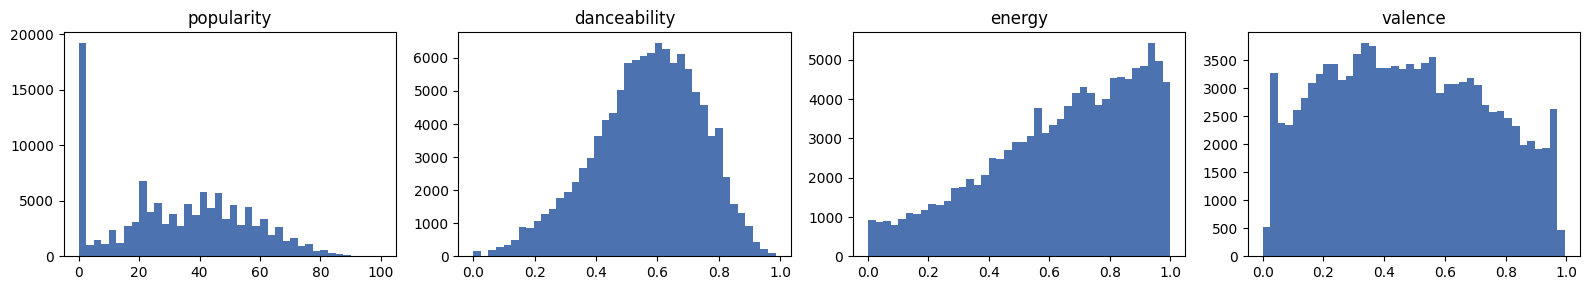

,popularity,danceability,energy,valence
count,114000.00,114000.00,114000.00,114000.00
mean,33.24,0.57,0.64,0.47
std,22.31,0.17,0.25,0.26
min,0.00,0.00,0.00,0.00
25%,17.00,0.46,0.47,0.26
50%,35.00,0.58,0.68,0.46
75%,50.00,0.70,0.85,0.68
max,100.00,0.98,1.00,1.00


In [4]:
num=['popularity', 'danceability', 'energy', 'valence']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

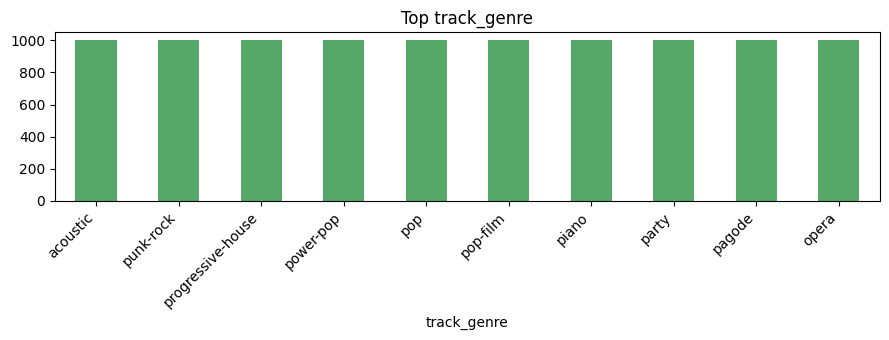

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000


In [5]:
vc=utils.top_counts(df['track_genre'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top track_genre'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above (size, missingness, distributions, dominant categories) frames the domain questions answered in notebook **02 — Analysis**, where the real insights and headline numbers (reported in the README) come from.